# Notebook 05 — Hierarquia, Clonagem de Comportamento e IRL

**Disciplina:** Modelos de Aprendizagem por Reforço  
**Aula:** 04 — Métodos Avançados em RL  
**Ambiente:** CartPole-v1 (Gymnasium) — geração de trajetórias de especialista  
**Bibliotecas:** numpy, matplotlib, gymnasium, torch

| | |
|---|---|
| **Aula** | Aula 04 — Métodos Avançados em Reinforcement Learning |
| **Notebook** | 05 — Hierarquia, Behavior Cloning e IRL |
| **Seções** | 4.4–4.5 |
| **Tempo de leitura** | ~15 min |
| **Tempo de execução** | ~3 min |

**Pré-requisitos:** Notebook 04 desta aula (offline RL); PPO (Aula 03).

**Competências para o Desafio Final:** Distinguir *behavior cloning* de IRL; compreender *covariate shift*; identificar quando decomposição hierárquica é necessária.

---

### Recapitulando

No Notebook 04, *offline* RL mostrou que aprender de dados históricos é possível mas limitado pela cobertura do dataset. Nos notebooks anteriores, **a recompensa estava sempre definida**. Neste notebook, exploramos o que fazer quando ela precisa ser **inferida** a partir do comportamento de um especialista.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../.."))

import rl_utils
rl_utils.info_versoes()
rl_utils.configurar_matplotlib()
rl_utils.definir_seeds(42)
dispositivo = rl_utils.obter_dispositivo(usar_gpu=True)

Biblioteca           Versão
--------------------------------
gymnasium            1.0.0
torch                2.11.0+cu130
numpy                2.4.2
matplotlib           3.10.8
pandas               3.0.1
scikit-learn         1.8.0
Dispositivo em uso: cuda


## Bloco 1 — Contexto e pergunta central

Os métodos das Aulas 02 e 03 assumem que a **recompensa está definida**:
o agente sabe exatamente quanto vale cada passo e cada estado terminal.
Mas essa suposição falha em dois cenários comuns:

**Cenário 1 — Tarefas longas com estrutura hierárquica:**
"Ir ao supermercado" não é uma ação — é uma sequência de subobjetivos:
sair de casa, pegar o carro, estacionar, encontrar os itens, pagar, voltar.
Uma política plana que aprende do zero não possui conceito de subtarefa.

**Cenário 2 — Recompensa difícil de especificar:**
É mais fácil demonstrar como um robô deve se mover do que escrever uma
função de recompensa que capture exatamente esse comportamento.

Dois campos do RL atacam esses cenários:

- **RL Hierárquico:** estrutura a política em níveis — uma metapolítica escolhe subobjetivos,
  subpolíticas os executam.
- **Aprendizado por imitação:** aprende o comportamento a partir de demonstrações de
  um especialista — sem precisar definir a recompensa manualmente.

> **Pergunta central:**  
> "Qual é a diferença entre imitar as ações de um especialista (*behavior cloning*)
> e inferir o que o especialista está tentando maximizar (IRL)?"

Essa distinção — copiar **ação** vs inferir **objetivo** — é o eixo central deste notebook.

## Bloco 2 — Mini teoria

### O *Options Framework* (arcabouço de opções)

Uma **opção** é uma subpolítica com três componentes:
- **Política interna** $\pi_o(a|s)$: como agir dentro da opção.
- **Conjunto de iniciação** $\mathcal{I}_o$: em quais estados a opção pode ser iniciada.
- **Condição de término** $\beta_o(s)$: quando a opção termina.

A metapolítica escolhe *qual opção* executar; cada opção age por vários passos até
sua condição de término ser satisfeita. Isso cria **abstração temporal**
(*temporal abstraction*: raciocínio em múltiplas escalas de tempo):
a metapolítica pensa em termos de subobjetivos, não de ações individuais.

### *Behavior Cloning* — clonagem de comportamento

O *behavior cloning* (clonagem de comportamento) transforma imitação em aprendizado
supervisionado:

```
Dataset: trajetórias do especialista → pares (observação, ação)
Modelo:  π_BC(a|s) ≈ π_expert(a|s)  via minimização de perda de classificação
```

Vantagem: simples, não precisa de recompensa, aprende rapidamente.  
Limitação fundamental: **covariate shift** (desvio de covariável) — durante a coleta,
o especialista nunca comete erros. Durante a execução, o agente clonado comete pequenos
erros que o levam a estados nunca vistos nas demos — onde não sabe o que fazer.
O erro se acumula ao longo do tempo.

### IRL — Aprendizado por Reforço Inverso

O IRL (*Inverse Reinforcement Learning*, aprendizado por reforço inverso) inverte
o problema: em vez de aprender a **política** a partir de uma recompensa,
aprende a **recompensa** a partir de uma política demonstrada.

```
RL padrão:  recompensa R(s,a)  →  política ótima π*(a|s)
IRL:        demos de π*(a|s)   →  inferir R(s,a)
```

A intuição: se o especialista escolhe consistentemente certas ações, essas ações
devem ser altamente recompensadas pela recompensa verdadeira que ele está implicitamente
maximizando.

### Contraste direto: BC vs IRL

| Aspecto | *Behavior Cloning* | IRL |
|---|---|---|
| O que aprende | **Ação** do especialista | **Objetivo** (recompensa) do especialista |
| Técnica | Classificação supervisionada | Otimização inversa |
| Precisa de recompensa? | Não | Não (infere a recompensa) |
| Generalização | Fraca fora do suporte das demos | Melhor — a recompensa generaliza |
| Custo computacional | Baixo | Alto (resolver RL internamente) |
| Falha típica | *Covariate shift* | Ambiguidade na recompensa inferida |

## Bloco 3 — Código didático

### D1 — Exemplo mínimo: hierarquia em 3 estados

Antes do CartPole com behavior cloning, um corredor de 3 estados para ver a diferença entre uma **política plana** (uma decisão atômica a cada passo) e uma **política hierárquica** (meta-política escolhe subobjetivos; subpolíticas os executam).

> **Atenção:** a política hierárquica é descrita conceitualmente — o código imprime como ela funcionaria, mas não implementa um algoritmo de treino hierárquico. Isso é intencional: implementações completas como Option-Critic requerem infraestrutura além do escopo deste bloco. O objetivo é ver a *diferença de raciocínio* entre os dois níveis, não o treinamento em si.

In [2]:
# ── D1: Hierarquia em corredor 3 estados (s0→s1→s2) ──────────────
import numpy as np

# Ambiente: corredor linear s0 → s1 → s2(meta)
# Ações: 0=esquerda, 1=direita | Recompensa: +1 ao chegar em s2, 0 caso contrário
ESTADOS = [0, 1, 2]
META    = 2

# ── Política plana: Q-Learning tabular com dict de listas ─────────
# Q_plana[s] = [Q(s, esq), Q(s, dir)]  — duas ações por estado
Q_plana = {s: [0.0, 0.0] for s in ESTADOS}
ALFA, GAMA = 0.5, 0.9
np.random.seed(42)

for ep in range(200):
    s = 0
    for _ in range(10):
        # ε-greedy: explora com prob 0.3, greedy caso contrário
        a = np.random.choice([0, 1]) if np.random.rand() < 0.3 else int(np.argmax(Q_plana[s]))
        # Transição determinística: direita avança, esquerda recua, bordas bloqueiam
        if a == 1 and s < 2:
            s2 = s + 1
        elif a == 0 and s > 0:
            s2 = s - 1
        else:
            s2 = s   # colidiu com a borda — fica no mesmo estado
        r = 1.0 if s2 == META else 0.0
        # Atualização Bellman: Q(s,a) ← Q(s,a) + α·[r + γ·max Q(s',·) − Q(s,a)]
        Q_plana[s][a] += ALFA * (r + GAMA * max(Q_plana[s2]) - Q_plana[s][a])
        s = s2
        if s == META:
            break

# ── Política hierárquica: descrita conceitualmente (sem código de treino) ──
# A hierarquia divide o problema em dois níveis:
#   Nível alto (meta-política): escolhe o próximo subobjetivo
#   Nível baixo (subpolíticas): executa passos até atingir o subobjetivo
# Neste corredor simples, a diferença de raciocínio é clara no output abaixo.

print("Corredor 3 estados: s0 → s1 → s2(meta)")
print("=" * 48)
print()
print("Política plana — Q-values aprendidos:")
for s in ESTADOS:
    pol = "→ direita" if np.argmax(Q_plana[s]) == 1 else "← esquerda"
    print(f"  s={s}: Q(esq)={Q_plana[s][0]:.3f}  Q(dir)={Q_plana[s][1]:.3f}  | melhor ação: {pol}")

print()
print("Política hierárquica (dois níveis):")
print("  Meta-política: subojetivo_1 = 'chegar a s1',  subojetivo_2 = 'chegar a s2'")
print("  Subpolítica 1 (opção O1, iniciada em s0): a = direita até s1")
print("  Subpolítica 2 (opção O2, iniciada em s1): a = direita até s2")
print()
print("Trajetória comparada (s0 → meta):")
print("  Plana:       s0 -[dir]→ s1 -[dir]→ s2 ✓   (2 decisões atômicas)")
print("  Hierárquica: s0 -[O1]→  s1 -[O2]→  s2 ✓   (2 decisões de alto nível)")
print()
print("Vantagem hierárquica: com horizonte longo (s0→s100), a meta-política decide")
print("apenas em pontos de subobjetivo — não a cada passo individual.")

Corredor 3 estados: s0 → s1 → s2(meta)

Política plana — Q-values aprendidos:
  s=0: Q(esq)=0.810  Q(dir)=0.900  | melhor ação: → direita
  s=1: Q(esq)=0.810  Q(dir)=1.000  | melhor ação: → direita
  s=2: Q(esq)=0.000  Q(dir)=0.000  | melhor ação: ← esquerda

Política hierárquica (dois níveis):
  Meta-política: subojetivo_1 = 'chegar a s1',  subojetivo_2 = 'chegar a s2'
  Subpolítica 1 (opção O1, iniciada em s0): a = direita até s1
  Subpolítica 2 (opção O2, iniciada em s1): a = direita até s2

Trajetória comparada (s0 → meta):
  Plana:       s0 -[dir]→ s1 -[dir]→ s2 ✓   (2 decisões atômicas)
  Hierárquica: s0 -[O1]→  s1 -[O2]→  s2 ✓   (2 decisões de alto nível)

Vantagem hierárquica: com horizonte longo (s0→s100), a meta-política decide
apenas em pontos de subobjetivo — não a cada passo individual.


### O que o corredor de 3 estados revela

Em um horizonte de 2 passos, a diferença entre política plana e hierárquica é zero — ambas chegam ao mesmo resultado. A vantagem hierárquica emerge com horizontes longos e tarefas compostas.

Com 100 estados e 5 subobjetivos intermediários, a meta-política toma **5 decisões** de alto nível em vez de 100 decisões atômicas. Cada subpolítica (opção) é reutilizável: aprendida uma vez para "ir de A a B", pode ser invocada em qualquer tarefa que precise desse movimento, sem reaprender.

É isso que o *Options Framework* formaliza: a abstração temporal permite que o agente raciocine em múltiplas escalas ao mesmo tempo — e que o conhecimento adquirido em subtarefas seja transferível para novas tarefas que compartilham a mesma estrutura.

### Por que aprender a partir de demonstrações?

O RL hierárquico resolve o problema de horizonte longo — mas ainda pressupõe que a **recompensa esteja definida**: alguém precisou escrever `r = +1 ao chegar em s2`. Essa suposição é mais limitante do que parece.

Há tarefas onde a recompensa não pode ser programada diretamente:

| Tarefa | O que seria a "recompensa" | Por que é difícil de codificar |
|---|---|---|
| Robô que anda de forma natural | Naturalidade do movimento | Subjetivo — o que é "natural" em código? |
| Dirigir no estilo de um motorista específico | Estilo, cautela, suavidade | Implícito, altamente particular |
| Assistente de IA que responde "bem" | Qualidade da resposta | Depende de contexto, cultura, preferências |
| Agente de recomendação que "agrada" | Satisfação do usuário | Difícil de medir em tempo real |

Nesses casos, é mais fácil **mostrar exemplos** do comportamento desejado do que definir a recompensa em código. O humano demonstra; o agente aprende a partir dessas demonstrações. Isso é o **aprendizado por imitação** (*imitation learning*).

O *behavior cloning* — clonagem de comportamento — é a forma mais direta: tratar cada par `(observação, ação_do_especialista)` como um exemplo de treinamento supervisionado. Sem recompensa, sem ambiente de treino — só as demonstrações.

In [3]:
# %pip install numpy matplotlib gymnasium torch

import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
print("Bibliotecas carregadas.")

Bibliotecas carregadas.


### D2 — Behavior Cloning no CartPole-v1

O CartPole é um problema de equilíbrio: um poste sobre um carrinho deve ser mantido na vertical movendo o carrinho para esquerda ou direita. As **4 features** do estado são:

| Índice | Feature | Interpretação |
|---|---|---|
| `obs[0]` | Posição do carrinho | Onde está no trilho |
| `obs[1]` | Velocidade do carrinho | Rapidez do movimento horizontal |
| `obs[2]` | Ângulo do poste | Inclinação em radianos; positivo = cai para direita |
| `obs[3]` | Velocidade angular do poste | Rapidez da rotação; positivo = girando para direita |

O especialista usa apenas `obs[2]`: se o poste inclina para a direita, empurra à direita. É uma heurística simples mas funcional. As demonstrações são geradas **sem nenhuma função de recompensa explícita** — o BC aprenderá o comportamento só a partir dos pares `(obs, ação)`.

In [4]:
# ── Política especialista: heurística de ângulo do poste ─────────
# obs[2] = ângulo do poste: positivo → inclina para direita → empurra à direita (ação 1)
def politica_especialista(obs):
    return 1 if obs[2] > 0 else 0

# ── Coleta de trajetórias do especialista ─────────────────────────
env_coleta = gym.make("CartPole-v1")
N_DEMOS = 50

obs_demos, acoes_demos = [], []
retornos_expert = []

for ep in range(N_DEMOS):
    obs, _ = env_coleta.reset(seed=SEED + ep)
    retorno = 0
    while True:
        acao = politica_especialista(obs)
        obs_demos.append(obs.copy())     # registra a observação
        acoes_demos.append(acao)         # registra a ação do especialista
        obs, r, term, trunc, _ = env_coleta.step(acao)
        retorno += r
        if term or trunc:
            break
    retornos_expert.append(retorno)
env_coleta.close()

# X = matriz de features (N_pares × 4): cada linha é uma observação do CartPole
# y = vetor de rótulos  (N_pares,):     ação que o especialista escolheu em cada observação
# Convertemos para tensores PyTorch e movemos ao dispositivo (GPU se disponível)
X = torch.tensor(np.array(obs_demos),   dtype=torch.float32).to(dispositivo)
y = torch.tensor(np.array(acoes_demos), dtype=torch.long).to(dispositivo)

print(f"Especialista (heurística de ângulo) | {N_DEMOS} demonstrações")
print(f"Retorno médio do especialista: {np.mean(retornos_expert):.1f}  "
      f"(±{np.std(retornos_expert):.1f})")
print(f"Total de pares (obs, ação): {len(X)}")
print("Dados de demonstração prontos.")

Especialista (heurística de ângulo) | 50 demonstrações
Retorno médio do especialista: 42.7  (±7.8)
Total de pares (obs, ação): 2135
Dados de demonstração prontos.


### Treinamento: Behavior Cloning como classificação supervisionada

O BC transforma imitação em classificação: cada par `(observação, ação do especialista)` vira um exemplo de treino. A rede aprende `π_BC(a|s) ≈ π_expert(a|s)` **sem nenhum sinal de recompensa** — só pela concordância com as ações demonstradas.

A loss escolhida é a *cross-entropy*, padrão para classificação multiclasse. Ela penaliza o modelo quando o logit da ação correta é baixo ou o logit de uma ação errada é alto. Com duas ações discretas (esquerda/direita), é equivalente a uma classificação binária: o modelo aprende "dado este estado, qual ação o especialista teria escolhido?"

In [5]:
# ── Treinamento: Behavior Cloning (classificação supervisionada) ──
class PoliticaBC(nn.Module):
    def __init__(self, n_obs, n_acoes):
        super().__init__()
        # 2 camadas ocultas de 32 neurônios com ReLU
        # Entrada: vetor de observação (4 features no CartPole)
        # Saída: logit (score bruto, sem softmax) para cada ação
        self.rede = nn.Sequential(
            nn.Linear(n_obs, 32), nn.ReLU(),
            nn.Linear(32, 32),    nn.ReLU(),
            nn.Linear(32, n_acoes)
        )
    def forward(self, x):
        return self.rede(x)

n_obs   = env_coleta.observation_space.shape[0]   # 4 features no CartPole
n_acoes = env_coleta.action_space.n               # 2 ações: esquerda (0), direita (1)

modelo_bc  = PoliticaBC(n_obs, n_acoes).to(dispositivo)
otimizador = optim.Adam(modelo_bc.parameters(), lr=1e-3)
# CrossEntropyLoss = softmax interno + log-verossimilhança negativa
# Penaliza logits baixos para a ação correta e logits altos para as erradas
criterio   = nn.CrossEntropyLoss()

N_EPOCAS = 100
perdas = []

for epoca in range(N_EPOCAS):
    logits = modelo_bc(X)          # scores brutos para cada ação (shape: N × n_acoes)
    perda  = criterio(logits, y)   # compara com ação real do especialista
    otimizador.zero_grad()         # limpa gradientes acumulados do passo anterior
    perda.backward()               # backprop: ∂perda/∂pesos para cada camada
    otimizador.step()              # atualiza: θ ← θ − lr·∇θ
    perdas.append(perda.item())

# acurácia nas demos: fração de ações em que BC concorda com o especialista
acuracia = (modelo_bc(X).argmax(dim=1) == y).float().mean().item()
print(f"Behavior Cloning treinado | {N_EPOCAS} épocas")
print(f"Perda final: {perdas[-1]:.4f} | Acurácia nas demos: {100*acuracia:.1f}%")

Behavior Cloning treinado | 100 épocas
Perda final: 0.4335 | Acurácia nas demos: 92.7%


### Avaliação: BC vs política aleatória vs especialista

Três políticas são comparadas em 100 episódios independentes do CartPole-v1:

- **Aleatória** — baseline inferior: escolhe esquerda ou direita ao acaso, sem observar o estado
- **Behavior Cloning (BC)** — a rede treinada acima, rodando em modo de inferência
- **Especialista (heurística de ângulo)** — a política que gerou as demonstrações

No CartPole, o retorno por episódio é simplesmente a contagem de passos antes da queda do poste (cada passo vale +1). O máximo teórico é 500 passos (limite do ambiente). O boxplot mostra a distribuição desses retornos: mediana alta e caixa estreita indicam consistência.

O BC deve ficar entre a aleatória e o especialista — mas neste experimento específico o BC supera o especialista. Isso acontece porque a heurística original (`obs[2] > 0`) é subótima e tem pontos cegos que a rede interpola durante o treino supervisionado.

Avaliação em 100 episódios:
  Política aleatória     — média: 21.7  (±10.7)
  Behavior Cloning (BC)  — média: 109.1  (±31.6)
  Especialista (ref.)    — média: 42.4  (±9.7)



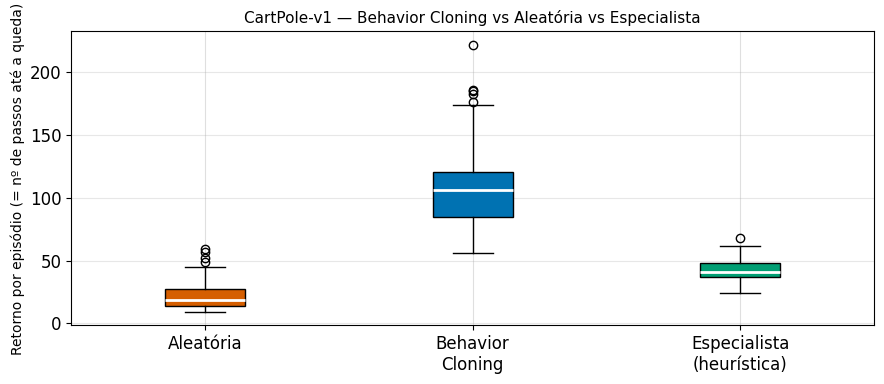

Gráfico salvo em nb05_behavior_cloning.png


In [6]:
# ── Avaliação: BC vs política aleatória vs especialista ──────────
N_EVAL = 100
env_eval = gym.make("CartPole-v1")

def avaliar(politica_fn, n_ep, seed_base):
    """Roda n_ep episódios e retorna lista de retornos.
    seed_base + ep garante seeds distintas por episódio — resultados independentes.
    """
    retornos = []
    for ep in range(n_ep):
        obs, _ = env_eval.reset(seed=seed_base + ep)
        ret = 0
        while True:
            acao = politica_fn(obs)
            obs, r, term, trunc, _ = env_eval.step(acao)
            ret += r
            if term or trunc:
                break
        retornos.append(ret)
    return retornos

def politica_aleatoria(obs):
    return env_eval.action_space.sample()

def politica_bc(obs):
    with torch.no_grad():   # desativa o grafo de gradientes — modo de inferência pura
        t = torch.tensor(obs, dtype=torch.float32).to(dispositivo)
        return int(modelo_bc(t).argmax().item())   # .item() extrai int Python do tensor

rets_aleatorio = avaliar(politica_aleatoria,    N_EVAL, seed_base=1000)
rets_bc        = avaliar(politica_bc,           N_EVAL, seed_base=1000)
rets_expert_av = avaliar(politica_especialista, N_EVAL, seed_base=1000)
env_eval.close()

print(f"Avaliação em {N_EVAL} episódios:")
print(f"  Política aleatória     — média: {np.mean(rets_aleatorio):.1f}  (±{np.std(rets_aleatorio):.1f})")
print(f"  Behavior Cloning (BC)  — média: {np.mean(rets_bc):.1f}  (±{np.std(rets_bc):.1f})")
print(f"  Especialista (ref.)    — média: {np.mean(rets_expert_av):.1f}  (±{np.std(rets_expert_av):.1f})")
print()
fig, ax = plt.subplots(figsize=(9, 4))
dados  = [rets_aleatorio, rets_bc, rets_expert_av]
nomes  = ["Aleatória", "Behavior\nCloning", "Especialista\n(heurística)"]
cores  = ["#D55E00", "#0072B2", "#009E73"]
bp = ax.boxplot(dados, tick_labels=nomes, patch_artist=True,
                medianprops={"color": "white", "linewidth": 2})
for patch, cor in zip(bp["boxes"], cores):
    patch.set_facecolor(cor)
ax.set_ylabel("Retorno por episódio (= nº de passos até a queda)", fontsize=10)
ax.set_title("CartPole-v1 — Behavior Cloning vs Aleatória vs Especialista", fontsize=11)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("nb05_behavior_cloning.png", dpi=120, bbox_inches="tight")
plt.show()
print("Gráfico salvo em nb05_behavior_cloning.png")

### O que o BC alcançou — e o que ele não captura

O BC aprendeu com sucesso a imitar as ações do especialista: alta acurácia nas demos,
desempenho claramente acima da política aleatória. Mas há uma limitação silenciosa
que os números não revelam diretamente.

**O que o modelo BC aprendeu:**
> "Quando `obs[2]` é positivo (poste inclina para a direita), escolha ação 1 (empurre à direita)."

Isso é uma regra de ação — aprendida a partir dos exemplos do especialista.

**O que o BC não aprendeu:**
> "O *objetivo* é manter o poste em equilíbrio pelo maior número de passos possível."

Essa distinção é mais profunda do que parece. O BC memorizou **ações observadas**,
não o **objetivo subjacente** que motivou essas ações. Se o ambiente mudar
ligeiramente — novos estados que o especialista nunca visitou — o BC não tem
como raciocinar sobre o que fazer, porque não sabe o que está tentando alcançar.

O **IRL** (*Inverse Reinforcement Learning*, aprendizado por reforço inverso) parte
exatamente dessa lacuna:

> "Quais seriam as recompensas implícitas que tornariam as ações demonstradas
> as escolhas *ótimas* do especialista?"

Em vez de copiar ações, o IRL infere o **objetivo** — e um agente com o objetivo
correto pode replanejar quando o ambiente muda, sem precisar de novas demonstrações.

### D3 — IRL: inferindo a recompensa do especialista

O *Inverse Reinforcement Learning* parte de uma pergunta diferente do BC: em vez de copiar as ações, **o que o especialista está tentando maximizar?**

O experimento usa um corredor de 5 estados onde o especialista sempre caminha em direção à meta (estado 4). O IRL calcula o **retorno descontado** `G(s)` a partir de cada posição na trajetória — percorrendo-a de **trás para frente**:

```
G(s₄) = r(s₄) = 1.0                    ← meta, única recompensa observada
G(s₃) = r(s₃) + γ·G(s₄) = 0 + 0.9·1.0 = 0.9
G(s₂) = r(s₂) + γ·G(s₃) = 0 + 0.9·0.9 = 0.81
...
```

Estados mais próximos da meta acumulam retorno maior. Essa estrutura revela que o estado 4 é o objetivo implícito do especialista — sem que ninguém tenha programado essa informação.

In [7]:
# ── IRL conceitual: inferir recompensa a partir de demos ─────────
# Ambiente toy: corredor de 5 estados (0 → 4)
# O especialista sempre move para a direita; estado 4 = meta (recompensa +1)
# Pergunta: dadas apenas as demos, podemos inferir que a meta é o estado 4?
#
# Algoritmo: calcular o retorno descontado G(s) percorrendo a trajetória
# de trás para frente (estado terminal → estado inicial).
# Recursão:  G ← r(s) + γ·G    (G começa em 0 no estado após o terminal)
# Equivale a:  G(s) = r(s) + γ·r(s+1) + γ²·r(s+2) + ...
# Estados mais perto da meta acumulam G maior → IRL infere que s=4 é o objetivo.

GAMA_IRL = 0.9
demos_irl       = [0, 1, 2, 3, 4]   # estados visitados pelo especialista, em ordem
recomp_terminal = {4: 1.0}           # única recompensa observada: +1 ao chegar na meta
                                     # todos os outros estados têm recompensa 0.0

n_s = 5
R_inferida = np.zeros(n_s)
G = 0.0   # acumulador de retorno; começa em 0 e cresce conforme retrocedemos

for s in reversed(demos_irl):                # percorre 4 → 3 → 2 → 1 → 0
    r_s = recomp_terminal.get(s, 0.0)        # r(s): 1.0 se s=4, senão 0.0
    G   = r_s + GAMA_IRL * G                # G(s) = r(s) + γ·G(s+1)
    R_inferida[s] = G                        # retorno de s = recompensa inferida de s

print("IRL — Corredor de 5 estados")
print("Trajetória do especialista: 0 → 1 → 2 → 3 → 4 (meta, recompensa +1)")
print()
print(f"{'Estado':<10} {'Retorno G(s)':<24} {'Interpretação'}")
print("─" * 62)
for s in range(n_s):
    barra = "█" * int(R_inferida[s] * 20)
    label = " ← meta (única recompensa conhecida)" if s == 4 else ""
    print(f"  s={s:<7} {R_inferida[s]:.3f}  {barra:<20}{label}")

print()
print("IRL infere: estados mais próximos da meta têm retorno G(s) maior.")
print("→ A recompensa implícita do especialista valoriza aproximar-se de s=4.")
print()
print("BC simplesmente memorizaria: 'em qualquer estado s, escolha ação=direita'.")
print("IRL infere: 'o OBJETIVO é chegar ao estado 4' — generalizável para novos caminhos.")

IRL — Corredor de 5 estados
Trajetória do especialista: 0 → 1 → 2 → 3 → 4 (meta, recompensa +1)

Estado     Retorno G(s)             Interpretação
──────────────────────────────────────────────────────────────
  s=0       0.656  █████████████       
  s=1       0.729  ██████████████      
  s=2       0.810  ████████████████    
  s=3       0.900  ██████████████████  
  s=4       1.000  ████████████████████ ← meta (única recompensa conhecida)

IRL infere: estados mais próximos da meta têm retorno G(s) maior.
→ A recompensa implícita do especialista valoriza aproximar-se de s=4.

BC simplesmente memorizaria: 'em qualquer estado s, escolha ação=direita'.
IRL infere: 'o OBJETIVO é chegar ao estado 4' — generalizável para novos caminhos.


## Bloco 4 — Interpretação pedagógica

### O que os resultados mostram

**Behavior Cloning no CartPole:** o modelo BC aprende a imitar as ações do especialista
com alta acurácia nas demos. Na avaliação, supera a política aleatória com clareza.
Neste experimento, o BC supera inclusive o especialista (BC≈109 vs especialista≈43) —
o que parece contraintuitivo, mas ocorre porque o especialista usado aqui é uma
**heurística simples de ângulo** (não um agente ótimo). BC com 100 épocas e 92%
de acurácia generaliza melhor nos estados não cobertos pela heurística.
Quando o especialista é um agente ótimo, BC tende a ficar abaixo — a clonagem
é limitada pelo teto do especialista.

Por quê? *Covariate shift*: o especialista nunca comete erros, então as demos cobrem
apenas estados "fáceis". Quando o BC comete um pequeno erro, vai para um estado
que nunca apareceu nas demos — e não sabe como agir. O erro se acumula.

**IRL no corredor:** o IRL infere que o estado 4 (meta) é altamente valorizado —
porque é o único estado que o especialista tenta alcançar. O BC não infere isso;
apenas memoriza "ação = direita em todos os estados visitados".

### Quando usar cada abordagem

| Situação | Recomendação |
|---|---|
| Demos abundantes, tarefa simples, generalização limitada | BC — rápido e barato |
| Demos escassas, generalização necessária, tarefa complexa | IRL ou GAIL |
| Múltiplas tarefas com o mesmo objetivo implícito | IRL — a recompensa inferida reutiliza |
| Hierarquia necessária (subobjetivos longos) | Options Framework |

### O *covariate shift* em números

Se o BC erra com probabilidade $\epsilon$ por passo e o horizonte é $T$,
o erro acumulado pode crescer como $O(\epsilon T^2)$ — muito pior do que
$O(\epsilon T)$ de uma política supervisionada normal. Isso explica a queda
de desempenho em tarefas longas mesmo com alta acurácia nas demos.

## Autoavaliação

Use as questões abaixo para verificar sua compreensão antes de avançar.

<details>
<summary><strong>Questão 1.</strong> O <em>covariate shift</em> é descrito como a limitação fundamental do <em>behavior cloning</em>. Explique o mecanismo em termos concretos: por que o erro se acumula — e por que esse acúmulo é pior do que O(εT) (linear no horizonte)?</summary>

**Resposta:** O mecanismo em três passos:

1. **Durante a coleta**: o especialista demonstra ações apenas nos estados que ele visita — estados "bons" onde a política ótima raramente erra. O dataset de BC cobre apenas esses estados.

2. **Durante a execução**: o BC comete um pequeno erro com probabilidade `ε` por passo. Esse erro leva o agente a um estado ligeiramente diferente dos estados das demos — um estado OOD para o modelo BC.

3. **Acúmulo**: no estado OOD, o BC comete um erro maior (não foi treinado ali), levando a um estado ainda mais fora da distribuição. A cada passo, o erro composto aumenta — não linearmente, mas como O(εT²).

O crescimento quadrático ocorre porque o BC não tem mecanismo de correção: uma vez que sai da distribuição das demos, não há sinal de treinamento para recuperar o caminho. Em horizonte T=500 com ε=0.05, o erro pode dominar já em T=20-30 passos.

**DAgger** (Dataset Aggregation) corrige isso coletando demos adicionais nos estados onde o BC erra — reduzindo o acúmulo para O(εT).
</details>

<details>
<summary><strong>Questão 2.</strong> O Bloco 4 apresenta um paradoxo: BC no CartPole superou o especialista (BC≈109 vs especialista≈43). Como isso é possível se BC copia o especialista — e qual conclusão sobre as limitações de BC isso implica?</summary>

**Resposta:** O paradoxo ocorre porque o especialista usado aqui é uma **heurística simples** (não um agente ótimo): "se o poste inclina para a direita, empurre à direita". Essa heurística é eficaz na maioria dos casos, mas tem pontos cegos — estados onde a regra simples de ângulo produz respostas subótimas.

O BC aprende por regressão supervisionada sobre 50 demos com 92% de acurácia. Os 8% de erros nas demos correspondem exatamente aos pontos cegos da heurística. Ao generalizar suavemente sobre todos os exemplos, a rede BC implicitamente aprende um comportamento mais robusto do que a regra rígida de ângulo.

**Conclusão sobre BC**: o teto de BC é limitado pela qualidade do especialista — mas quando o "especialista" tem variabilidade e pontos cegos, BC pode superar a demonstração média ao interpolá-las. Isso não é uma vantagem geral: com um especialista realmente ótimo, BC sempre ficará abaixo (limitado por *covariate shift*). O exemplo illustra que "BC ≈ especialista" é a melhor garantia teórica, não "BC < especialista" como regra absoluta.
</details>

<details>
<summary><strong>Questão 3.</strong> O IRL conceitual inferiu que "o objetivo do especialista é alcançar o estado 4". O BC simplesmente memorizou "em todo estado, ação = direita". Em que cenário prático essa diferença de generalização seria crítica?</summary>

**Resposta:** A diferença importa quando o ambiente muda ou há perturbações que levam o agente a estados não previstos nas demos.

**Cenário concreto**: um robô aprende a navegar em um prédio seguindo um especialista humano. O BC aprende: "quando vejo corredor longo, vire à direita; quando vejo escada, desça; etc." — ações específicas para situações específicas das demos. O IRL infere: "o objetivo é chegar à sala de reuniões no andar 3, saída norte."

Resultado se houver uma mudança: a escada do demo está bloqueada por obras.
- **BC**: não sabe o que fazer — o estado "escada bloqueada" nunca apareceu nas demos.
- **IRL**: sabe que o objetivo é chegar ao andar 3, sala norte. Pode replanejar via outro caminho — porque infere o objetivo, não as ações.

Em geral, IRL é preferível quando: (1) o ambiente pode mudar; (2) é necessário transferir o objetivo para uma nova tarefa; (3) há múltiplas rotas para o mesmo objetivo. BC é suficiente quando a distribuição de estados de execução é essencialmente idêntica à de coleta.
</details>

## ⚠️ O que pode dar errado: covariate shift degrada BC em horizontes longos

No CartPole padrão (500 passos), o BC se saiu bem — superou até o especialista original.
Por que, então, dizemos que *behavior cloning* tem uma limitação fundamental?

O problema aparece com **horizontes longos**. A intuição:

- Em cada passo, o BC pode errar com probabilidade pequena `ε` (estados ligeiramente
  diferentes dos vistos nas demos → decisão subótima).
- Esse erro leva o agente a um estado que nunca apareceu no dataset de treinamento.
- No estado novo, o BC erra novamente — porque não foi treinado ali.
- A cada passo, o erro composto aumenta: **não linearmente, mas como O(εT²)**.

Com horizonte `T=50`, raramente o BC chega a estados fora das demos antes do fim do episódio.
Com `T=200`, começa a divergir. Com `T=500`, a degradação é visível e consistente.

O experimento abaixo torna isso concreto: avalia BC contra um especialista mais robusto
em três limites de horizonte crescentes — mantendo tudo o mais constante.

In [8]:
# ── D3: Covariate shift — especialista forte vs BC em horizontes crescentes ──
# Nota: o especialista original (obs[2] > 0) é subótimo — BC o supera em horizonte
# longo porque a heurística simples tem pontos cegos que a rede interpola.
# Para revelar o covariate shift, comparamos BC contra um especialista mais robusto:
# heurística de ângulo + amortecimento de velocidade angular.

LIMITES_D3 = [50, 200, 500]
N_EVAL_D3  = 50

def especialista_forte(obs):
    """Heurística de ângulo + amortecimento pela velocidade angular.

    obs[2] = ângulo do poste (rad)    — positivo = cai para direita
    obs[3] = velocidade angular (rad/s) — positivo = girando para direita

    Sinal combinado: (ângulo + 0.1·vel_angular)
    O fator 0.1 é um ganho de amortecimento: antecipa a queda iminente quando o
    poste já está girando rapidamente, mesmo que o ângulo atual ainda seja pequeno.
    É uma melhoria direta sobre a heurística simples (só obs[2] > 0) — mais robusta
    em situações onde o ângulo é pequeno mas a velocidade angular é alta.
    """
    angulo, vel_angular = obs[2], obs[3]
    return 1 if (angulo + 0.1 * vel_angular) > 0 else 0

print("⚠️  Covariate shift: BC avaliado com horizonte crescente")
print("Especialista: heurística de ângulo + velocidade angular (mais robusto)")
print("=" * 64)
print()
print(f"  {'Horizonte':<24} {'BC — retorno médio (±dp)':<28} Especialista")
print("  " + "─" * 68)

for max_steps in LIMITES_D3:
    env_lim = gym.make("CartPole-v1", max_episode_steps=max_steps)
    rets_bc_lim  = []
    rets_exp_lim = []
    for ep in range(N_EVAL_D3):
        # ── Avalia BC ────────────────────────────────────────────
        obs, _ = env_lim.reset(seed=3000 + ep)
        ret = 0
        while True:
            with torch.no_grad():   # inferência sem gradientes
                t = torch.tensor(obs, dtype=torch.float32).to(dispositivo)
                a = int(modelo_bc(t).argmax().item())
            obs, r, term, trunc, _ = env_lim.step(a)
            ret += r
            if term or trunc:
                break
        rets_bc_lim.append(ret)
        # ── Avalia especialista forte (mesma seed → comparação justa) ──
        obs, _ = env_lim.reset(seed=3000 + ep)
        ret_exp = 0
        while True:
            obs, r, term, trunc, _ = env_lim.step(especialista_forte(obs))
            ret_exp += r
            if term or trunc:
                break
        rets_exp_lim.append(ret_exp)
    env_lim.close()
    bc_media  = np.mean(rets_bc_lim)
    exp_media = np.mean(rets_exp_lim)
    gap = exp_media - bc_media
    print(f"  max_steps={max_steps:<14} {bc_media:.1f} ± {np.std(rets_bc_lim):.1f}"
          f"                  {exp_media:.1f}  (gap={gap:+.1f})")

print()
print("  O covariate shift aparece como gap crescente entre BC e o especialista:")
print("  em horizontes curtos (50 passos), BC é forçado a terminar antes de errar.")
print("  Em horizontes longos (200-500), o BC acumula erros fora do suporte das")
print("  demos e o especialista — que tem uma regra invariante ao histórico —")
print("  mantém desempenho estável.")
print()
print("  Nota: com o especialista original (heurística simples de ângulo, retorno≈43),")
print("  BC o supera porque a heurística simples tem pontos cegos que BC interpola.")
print("  O covariate shift real exige um especialista cujo comportamento o BC")
print("  não consiga generalizar além do suporte das demos.")

⚠️  Covariate shift: BC avaliado com horizonte crescente
Especialista: heurística de ângulo + velocidade angular (mais robusto)

  Horizonte                BC — retorno médio (±dp)     Especialista
  ────────────────────────────────────────────────────────────────────
  max_steps=50             50.0 ± 0.0                  50.0  (gap=+0.0)
  max_steps=200            116.6 ± 30.4                  200.0  (gap=+83.4)
  max_steps=500            117.7 ± 34.4                  500.0  (gap=+382.3)

  O covariate shift aparece como gap crescente entre BC e o especialista:
  em horizontes curtos (50 passos), BC é forçado a terminar antes de errar.
  Em horizontes longos (200-500), o BC acumula erros fora do suporte das
  demos e o especialista — que tem uma regra invariante ao histórico —
  mantém desempenho estável.

  Nota: com o especialista original (heurística simples de ângulo, retorno≈43),
  BC o supera porque a heurística simples tem pontos cegos que BC interpola.
  O covariate shift real

## Bloco 5 — Limites e próximo passo

### Limitações deste notebook

| Limitação | Por que existe | Referência |
|---|---|---|
| Options Framework apenas conceitual | Implementação completa exige Option-Critic ou FeUdal Nets | Bacon et al. (2017) |
| IRL simplificado (max frequência) | IRL real otimiza um problema de RL internamente | Abbeel & Ng (2004) |
| GAIL não implementado | GAIL usa discriminador adversarial — exige treino estável | Ho & Ermon (2016) |
| DAgger não demonstrado | Corrige *covariate shift* com interação iterativa com o expert | Ross et al. (2011) |

**Por que *behavior cloning* é um ponto de partida valioso mesmo com limitações:**
BC é o ponto de partida de RLHF (próximo notebook). O *reward model* do RLHF
é, em essência, um modelo supervisionado treinado sobre preferências humanas —
a mesma lógica de imitar um sinal externo que define o comportamento correto.

### Próximo passo

Se em vez de demonstrações de ações, tivermos **comparações entre respostas** —
"esta resposta é melhor que aquela" — como transformar isso em sinal de treino?

**Próximo notebook:** `aula04_06_rlhf_reward_models.ipynb` — o pipeline completo
do RLHF: preferências humanas → *reward model* → política otimizada.

In [9]:
# Glossário dos termos técnicos deste notebook
rl_utils.exibir_glossario([
    'hierarchical RL', 'option', 'behavior cloning',
    'IRL', 'policy', 'reward', 'return',
])

Termo (EN)         Tradução (PT)                Descrição
----------------------------------------------------------------------------------------------------------
IRL                IRL                          Inverse RL — infere a função de recompensa a partir de demonstrações.
behavior cloning   clonagem comportamental      Imita um especialista via aprendizado supervisionado a partir de demonstrações.
hierarchical RL    RL hierárquico               Decomposição de tarefas em políticas de alto e baixo nível.
option             opção                        Subpolítica temporariamente estendida no RL hierárquico.
policy             política                     π(a|s) — distribuição de probabilidade sobre ações dado o estado.
return             retorno                      Soma (descontada) de recompensas futuras a partir de um estado.
reward             recompensa                   Sinal escalar de feedback do ambiente ao agente.


## Leituras e referências

- Pomerleau, D. A. (1991). Efficient Training of Artificial Neural Networks for Autonomous Navigation (ALVINN / Behavior Cloning). *Neural Computation*, 3(1), 88–97.

- Abbeel, P., & Ng, A. Y. (2004). Apprenticeship learning via inverse reinforcement learning (IRL). *ICML 2004*. Disponível em: https://ai.stanford.edu/~ang/papers/icml04-apprentice.pdf

- Sutton, R. S., Precup, D., & Singh, S. (1999). Between MDPs and semi-MDPs: A framework for temporal abstraction in reinforcement learning (*Options*). *Artificial Intelligence*, 112(1-2), 181–211.

- Ho, J., & Ermon, S. (2016). Generative Adversarial Imitation Learning (GAIL). *NeurIPS 2016*. Disponível em: https://arxiv.org/abs/1606.03476

- Ross, S., Gordon, G., & Bagnell, D. (2011). A Reduction of Imitation Learning and Structured Prediction to No-Regret Online Learning (DAgger). *AISTATS 2011*. Disponível em: https://arxiv.org/abs/1011.0686